In [42]:
%load_ext autoreload
%autoreload 2

import data_formater69 as df
import calib69 as calib
import matplotlib.pyplot as plt
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
with pd.ExcelWriter("modeldata_ra.xlsx") as writer:
    df.Y.unstack('TID').to_excel(writer, sheet_name="Y")
    df.Mtot.unstack('TID').to_excel(writer, sheet_name="M_tot")
    df.JKL.unstack('TID').to_excel(writer, sheet_name="JKL")
    df.KL.unstack('TID').to_excel(writer, sheet_name="KL")
    df.M_D.unstack('TID').to_excel(writer, sheet_name="M_D")
    df.M_F.unstack('TID').to_excel(writer, sheet_name="M_F")
    df.L.unstack('TID').to_excel(writer, sheet_name="L")
    df.J.unstack('TID').to_excel(writer, sheet_name="J")
    df.K.unstack('TID').to_excel(writer, sheet_name="K")
    df.MDtot.unstack('TID').to_excel(writer, sheet_name="MDtot")
    df.MFtot.unstack('TID').to_excel(writer, sheet_name="MFtot")
    
    df.P.unstack('TID').to_excel(writer, sheet_name="P")
    df.P_Mtot.unstack('TID').to_excel(writer, sheet_name="P_Mtot")
    df.P_JKL.unstack('TID').to_excel(writer, sheet_name="P_JKL")
    df.P_KL.unstack('TID').to_excel(writer, sheet_name="P_KL")
    df.P_D.unstack('TID').to_excel(writer, sheet_name="P_D")
    df.P_F.unstack('TID').to_excel(writer, sheet_name="P_F")
    df.w.unstack('TID').to_excel(writer, sheet_name="w")
    calib.P_J.to_frame().T.to_excel(writer, sheet_name="P_Jord")
    calib.P_K.unstack('TID').to_excel(writer, sheet_name="P_K")
    df.P_MDtot.unstack('TID').to_excel(writer, sheet_name="P_MDtot")
    df.P_MFtot.unstack('TID').to_excel(writer, sheet_name="P_MFtot")

C:\Users\b431385\AppData\Local\Temp\ipykernel_26124\279820554.py:19: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(years, theta_wide[branche], label=branche)


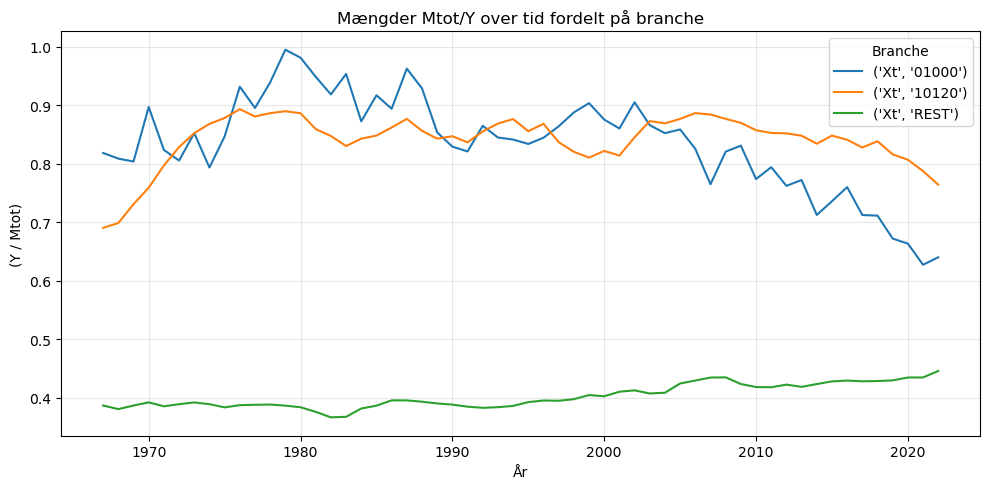

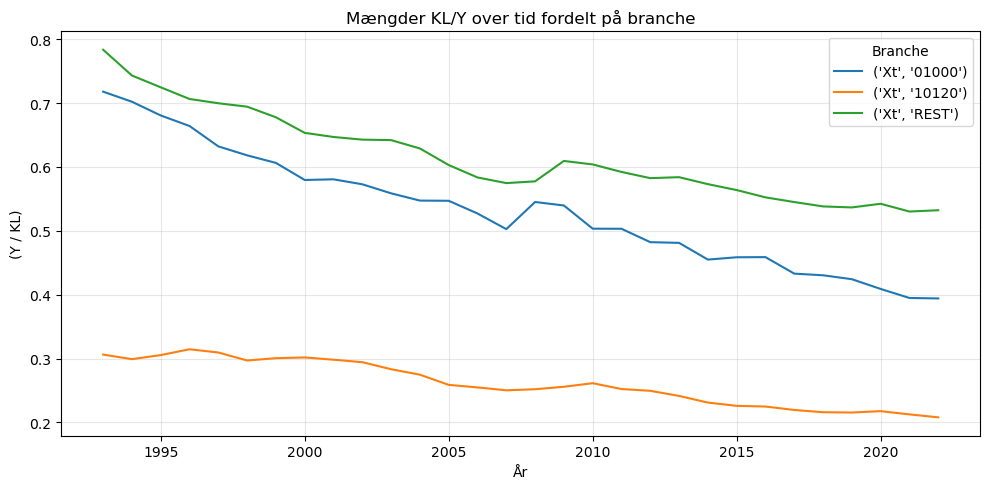

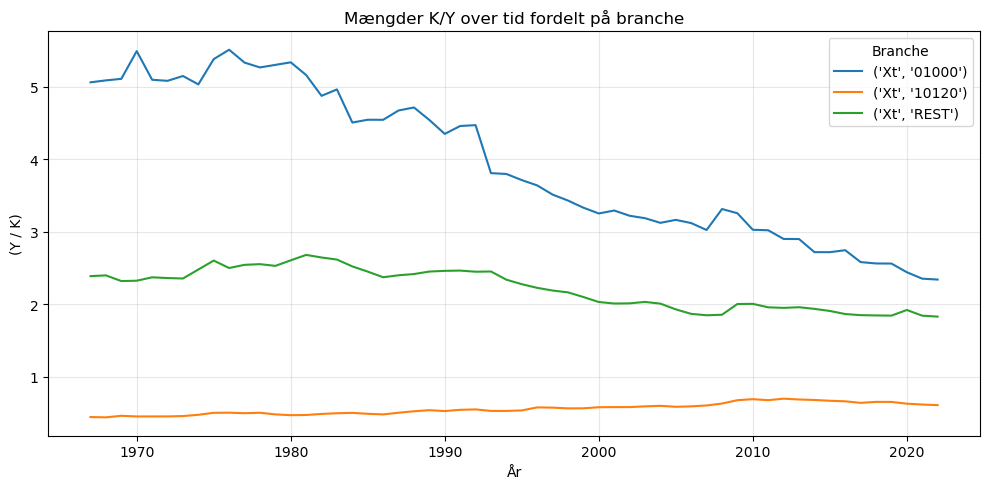

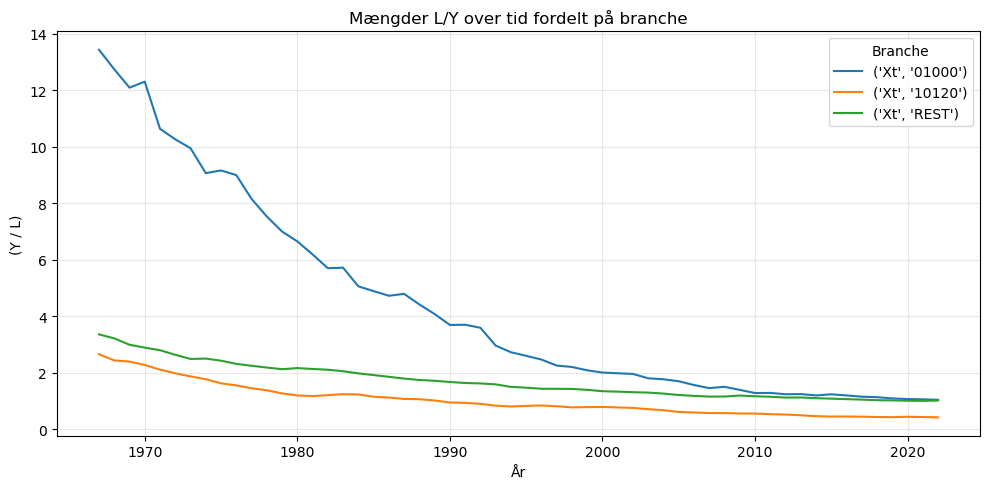

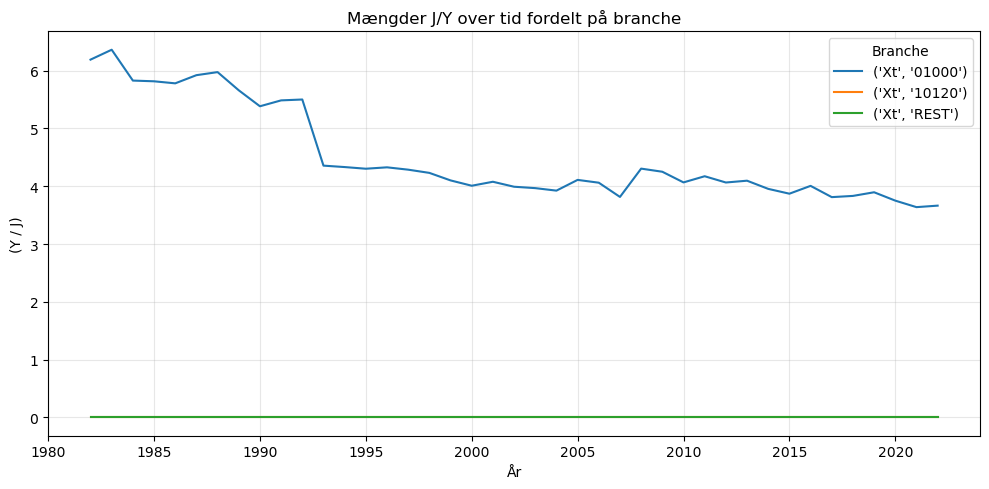

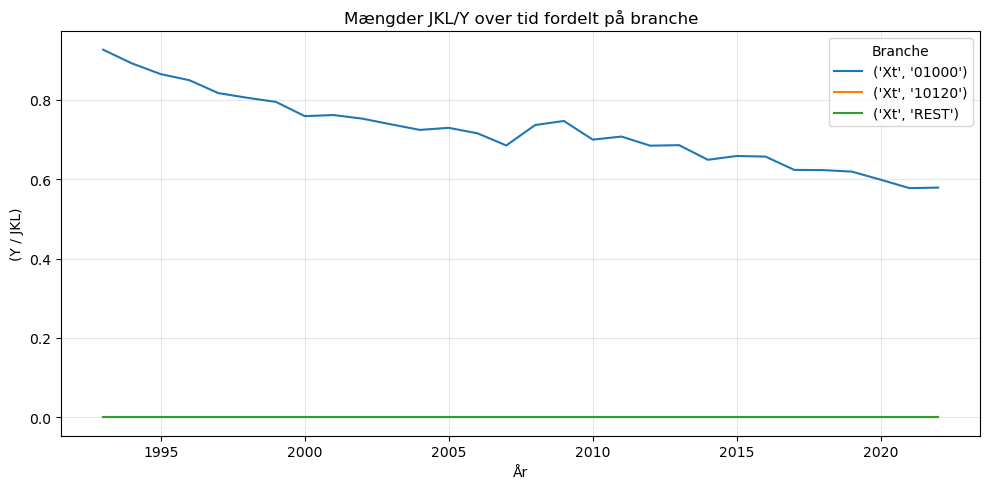

In [44]:
# Laver et loop over alle variable hvor jeg tager Y og dividerer med den givne variabel
#definerer de variable det drejer sig om
variables = ['Mtot', 'KL', 'K', 'L', 'J', 'JKL']
for variable in variables:
    setattr(df, f'{variable}_Y', getattr(df, variable)/df.Y )

# laver et plot over det nye variable over tid - hver branche som sin egen linje
for variable in variables:
    theta_var = getattr(df, f'{variable}_Y')
    
    # Håndter forskellige index-strukturer
    if 'ANVENDELSE' in theta_var.index.names:
        # Hvis der er branche-dimension, unstack den
        theta_wide = theta_var.unstack('ANVENDELSE').sort_index()
        years = theta_wide.index.get_level_values('TID') if 'TID' in theta_wide.index.names else theta_wide.index
        
        plt.figure(figsize=(10, 5))
        for branche in theta_wide.columns:
            plt.plot(years, theta_wide[branche], label=branche)
        plt.xlabel("År")
        plt.ylabel(f"(Y / {variable})")
        plt.title(f"Mængder {variable}/Y over tid fordelt på branche")
        plt.legend(title="Branche")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [45]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# Angiv PDF-filnavn
pdf_filename = "produktivitetsparametre_10120.pdf"

with PdfPages(pdf_filename) as pdf:
    # --- Figur 1 ---
    d = calib.theta_Y_KL_indeks.loc['10120', slice(1994, 2022)].copy()
    p = calib.theta_Y_Mtot_indeks.loc['10120', slice(1994, 2022)].copy()
    years = d.index.get_level_values('TID')

    plt.figure(figsize=(10,5))
    plt.plot(years, d.values, label=r'$\theta^{Y,KL}_{it}$  (Kapital + Arbejde)')
    plt.plot(years, p.values, label=r'$\theta^{Y,M}_{it}$  (Materialer)')
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title("Produktivitetsparametre – Branche 10120")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    pdf.savefig()  # Gem figuren i PDF
    plt.close()

    # --- Figur 2 ---
    branche = '10120'
    d = calib.theta_KL_K_indeks.loc[branche, slice(1994, 2022)]
    p = calib.theta_KL_L_indeks.loc[branche, slice(1994, 2022)]
    years = d.index.get_level_values('TID')

    plt.figure(figsize=(10,5))
    plt.plot(years, d.values, label=r'$\theta^{KL,K}_{it}$  (Kapital)')
    plt.plot(years, p.values, label=r'$\theta^{KL,L}_{it}$  (Arbejde)')
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title(f"Produktivitetsparametre – Branche {branche}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # --- Figur 3 ---
    d = calib.theta_Mtot_M_indeks.loc[('10120', slice(None), slice(1994, 2022))].copy()
    d_wide = d.unstack('TILGANG2').sort_index()
    years = d_wide.index.get_level_values('TID')

    plt.figure(figsize=(10,5))
    for col in d_wide.columns:
        plt.plot(years, d_wide[col], label=col)
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title(r'$\theta^{Mtot,M}_{it}$ Materiale-CES – Branche 10120')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # --- Figur 4: Landbrugssektor ---
    d = calib.theta_MD_indeks.loc[('10120','01000', slice(1994, 2022))].copy()
    p = calib.theta_MF_indeks.loc[('10120','01000', slice(1994, 2022))].copy()
    plt.figure(figsize=(10,5))
    plt.plot(years, d, label=r'$\theta^{MD}_{it}$ Danske materialer')
    plt.plot(years, p, label=r'$\theta^{MF}_{it}$ Importerede materialer')
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title(f"Materiale-CES – Landbrugssektor")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # --- Figur 5: Fødevaresektor ---
    d = calib.theta_MD_indeks.loc[('10120','10120', slice(1994, 2022))].copy()
    p = calib.theta_MF_indeks.loc[('10120','10120', slice(1994, 2022))].copy()
    plt.figure(figsize=(10,5))
    plt.plot(years, d, label=r'$\theta^{MD}_{it}$ Danske materialer')
    plt.plot(years, p, label=r'$\theta^{MF}_{it}$ Importerede materialer')
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title(f"Materiale-CES – Fødevaresektor")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # --- Figur 6: Resten af økonomien ---
    d = calib.theta_MD_indeks.loc[('10120','REST', slice(1994, 2022))].copy()
    p = calib.theta_MF_indeks.loc[('10120','REST', slice(1994, 2022))].copy()
    plt.figure(figsize=(10,5))
    plt.plot(years, d, label=r'$\theta^{MD}_{it}$ Danske materialer')
    plt.plot(years, p, label=r'$\theta^{MF}_{it}$ Importerede materialer')
    plt.xlabel("År")
    plt.ylabel("CES-andel")
    plt.title(f"Materiale-CES – Resten af økonomien")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

print(f"Alle figurer er gemt i {pdf_filename}")

Alle figurer er gemt i produktivitetsparametre_10120.pdf


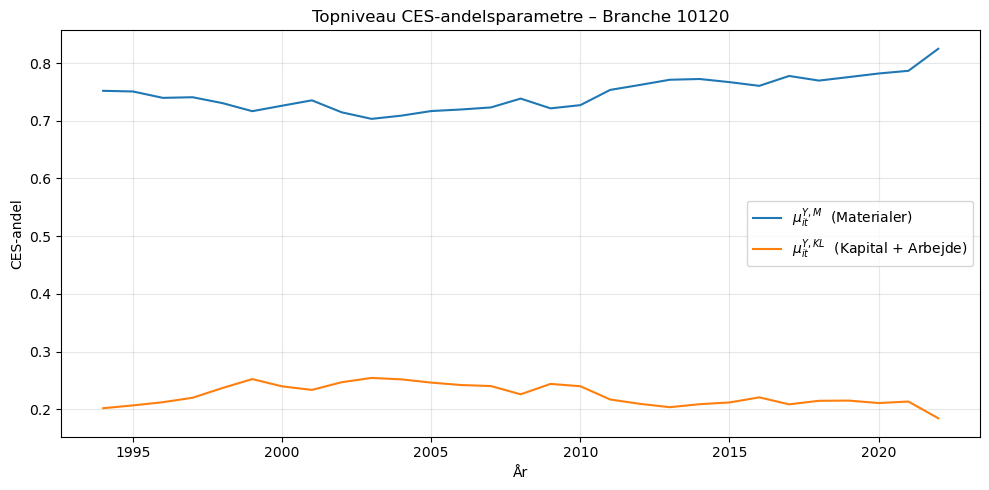

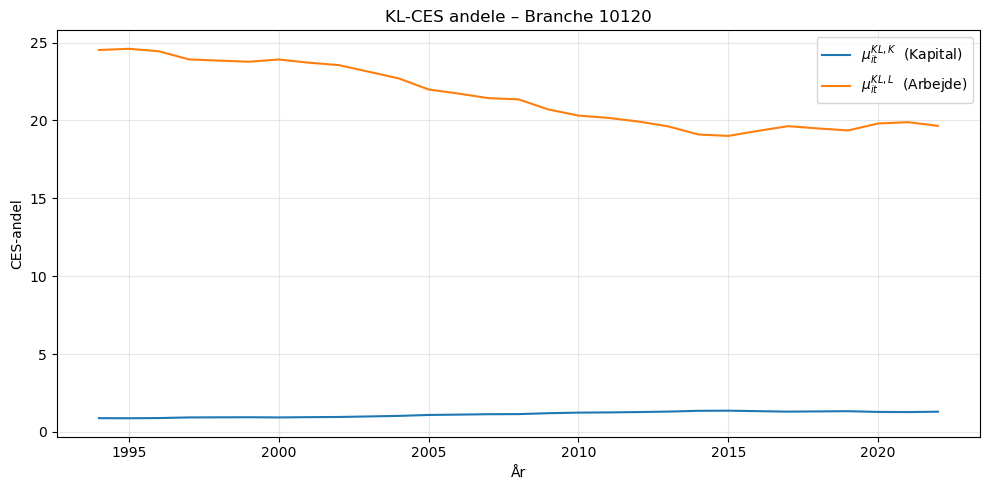

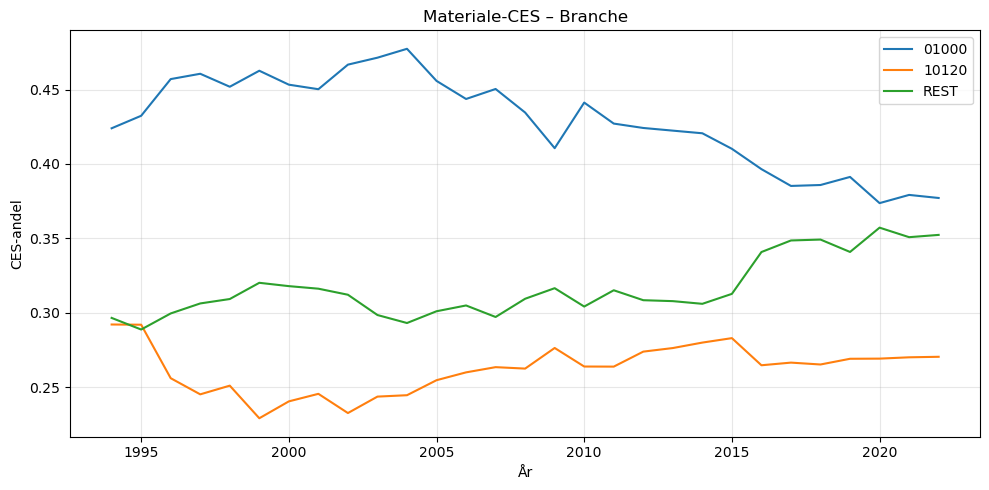

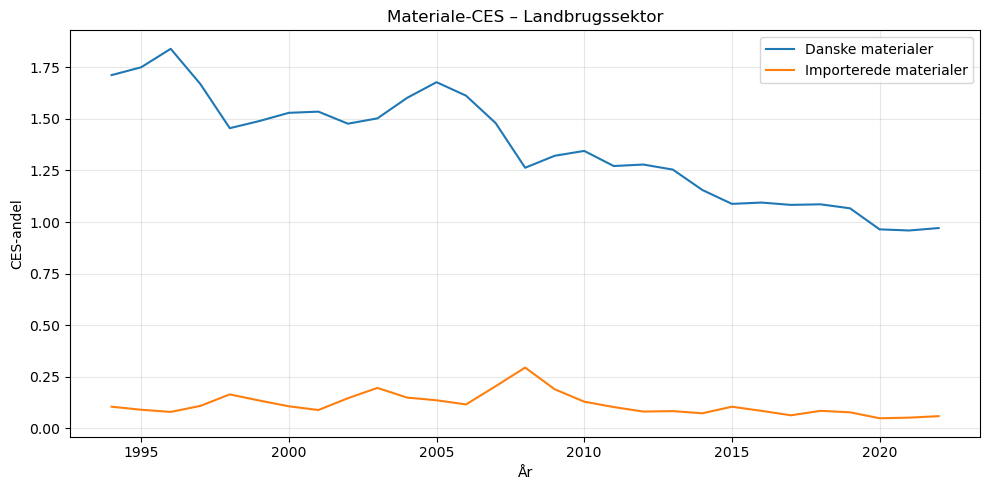

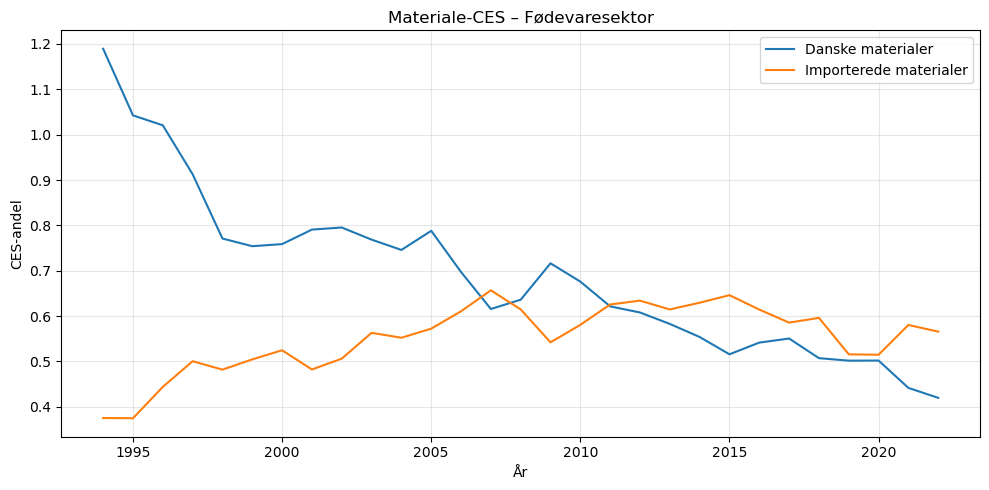

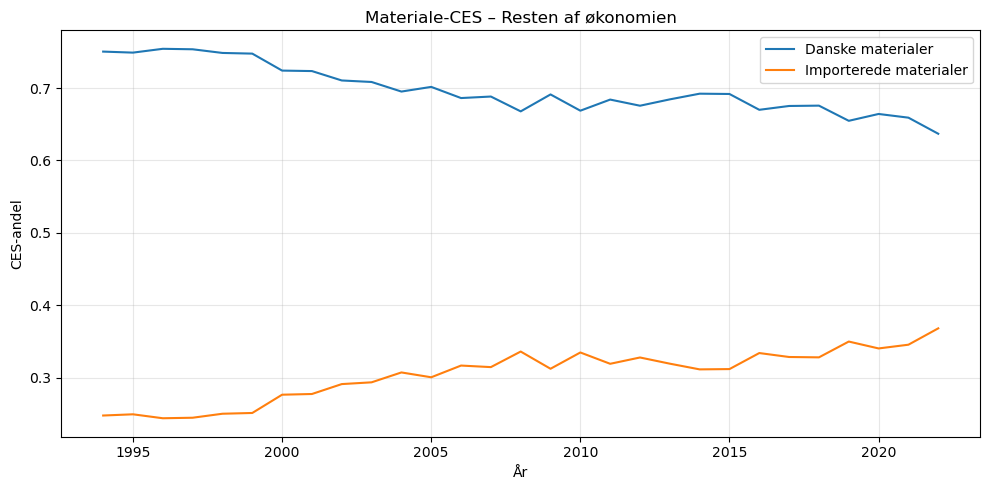

In [46]:
# Kun 1994 og frem
d = calib.mu_Y_Mtot.loc['10120', slice(1994, 2022)].copy()
p = calib.mu_Y_KL.loc['10120', slice(1994, 2022)].copy()

years = d.index.get_level_values('TID')

plt.figure(figsize=(10, 5))

plt.plot(years, d.values, label=r'$\mu^{Y,M}_{it}$  (Materialer)')
plt.plot(years, p.values, label=r'$\mu^{Y,KL}_{it}$  (Kapital + Arbejde)')

plt.xlabel("År")
plt.ylabel("CES-andel")
plt.title("Topniveau CES-andelsparametre – Branche 10120")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

branche = '10120'   # skift hvis ønsket

d = calib.mu_KL_K.loc[branche, slice(1994, 2022)]
p = calib.mu_KL_L.loc[branche, slice(1994, 2022)]

years = d.index.get_level_values('TID')

plt.figure(figsize=(10,5))
plt.plot(years, d.values, label=r'$\mu^{KL,K}_{it}$  (Kapital)')
plt.plot(years, p.values, label=r'$\mu^{KL,L}_{it}$  (Arbejde)')

plt.xlabel("År")
plt.ylabel("CES-andel")
plt.title(f"KL-CES andele – Branche {branche}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

d = calib.mu_Mtot_M.loc[('10120', slice(None), slice(1994, 2022))].copy()
d_wide = d.unstack('TILGANG2').sort_index()

# Extract years (TID) from the MultiIndex for plotting
years = d_wide.index.get_level_values('TID')

plt.figure(figsize=(10,5))
for branche in d_wide.columns:
    plt.plot(years, d_wide[branche], label=branche)
plt.xlabel("År")
plt.ylabel("CES-andel")
plt.title(f"Materiale-CES – Branche")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

d = calib.mu_MD.loc[('10120','01000', slice(1994, 2022))].copy()
p = calib.mu_MF.loc[('10120', '01000', slice(1994, 2022))].copy()


plt.figure(figsize=(10,5))
plt.plot(years, d, label='Danske materialer')
plt.plot(years, p, label='Importerede materialer')
plt.xlabel("År")
plt.ylabel("CES-andel")
plt.title(f"Materiale-CES – Landbrugssektor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

d = calib.mu_MD.loc[('10120','10120', slice(1994, 2022))].copy()
p = calib.mu_MF.loc[('10120', '10120', slice(1994, 2022))].copy()


plt.figure(figsize=(10,5))
plt.plot(years, d, label='Danske materialer')
plt.plot(years, p, label='Importerede materialer')
plt.xlabel("År")
plt.ylabel("CES-andel")
plt.title(f"Materiale-CES – Fødevaresektor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

d = calib.mu_MD.loc[('10120','REST', slice(1994, 2022))].copy()
p = calib.mu_MF.loc[('10120', 'REST', slice(1994, 2022))].copy()


plt.figure(figsize=(10,5))
plt.plot(years, d, label='Danske materialer')
plt.plot(years, p, label='Importerede materialer')
plt.xlabel("År")
plt.ylabel("CES-andel")
plt.title(f"Materiale-CES – Resten af økonomien")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

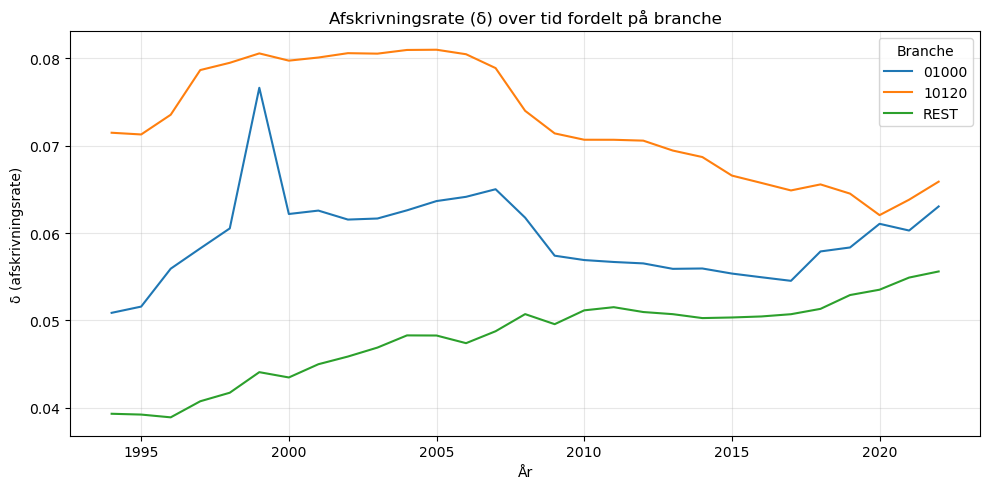

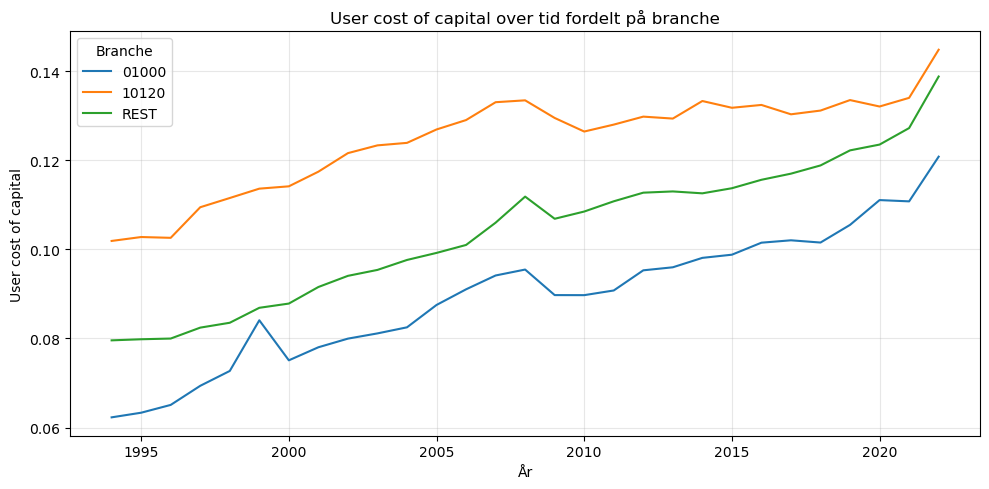

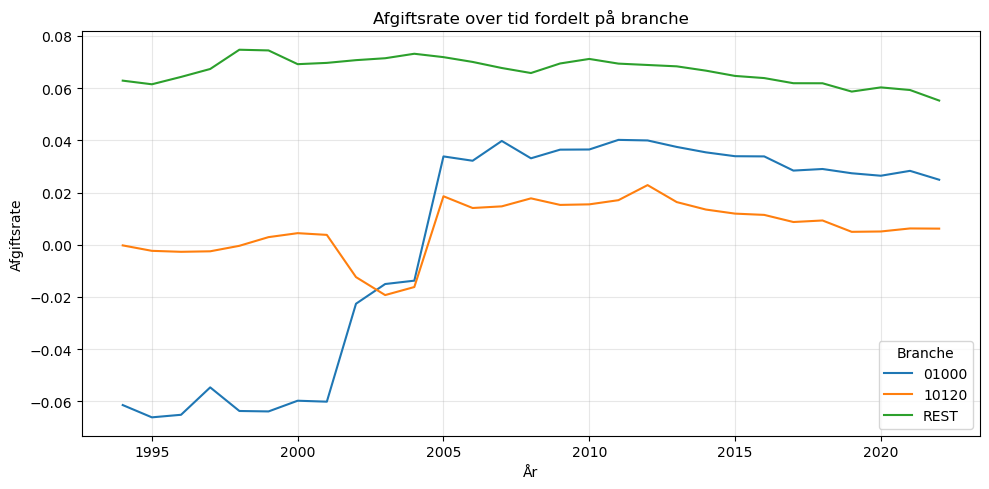

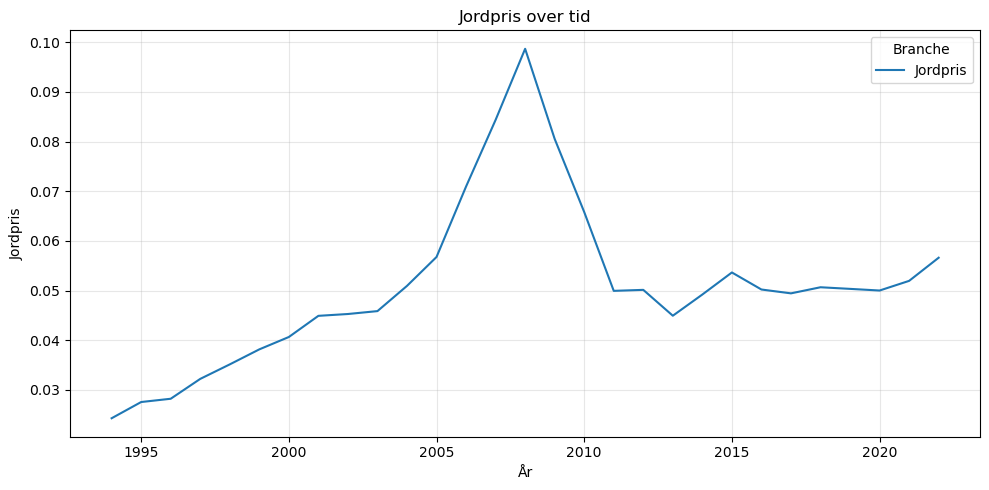

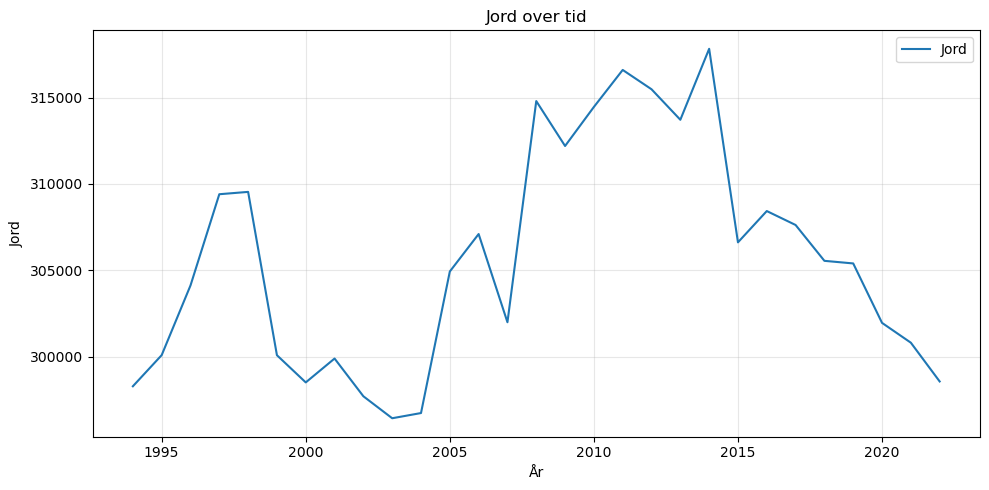

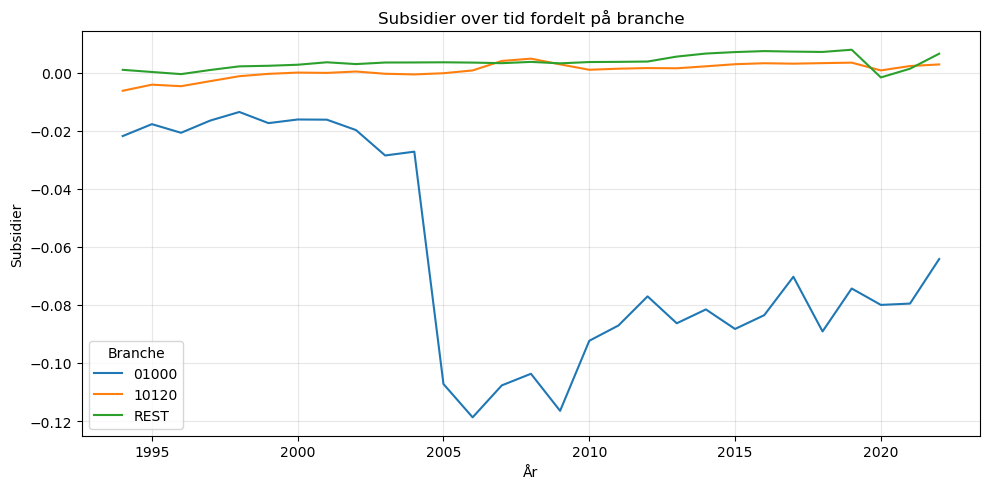

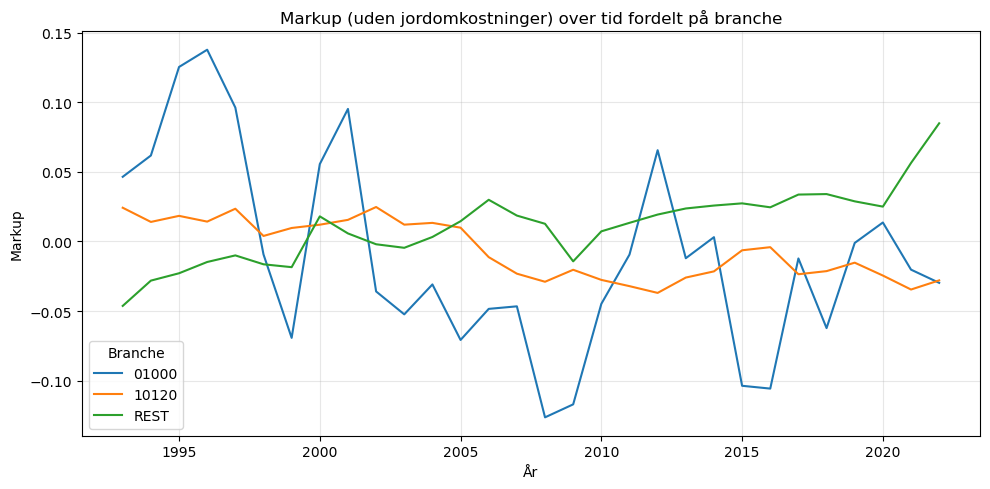

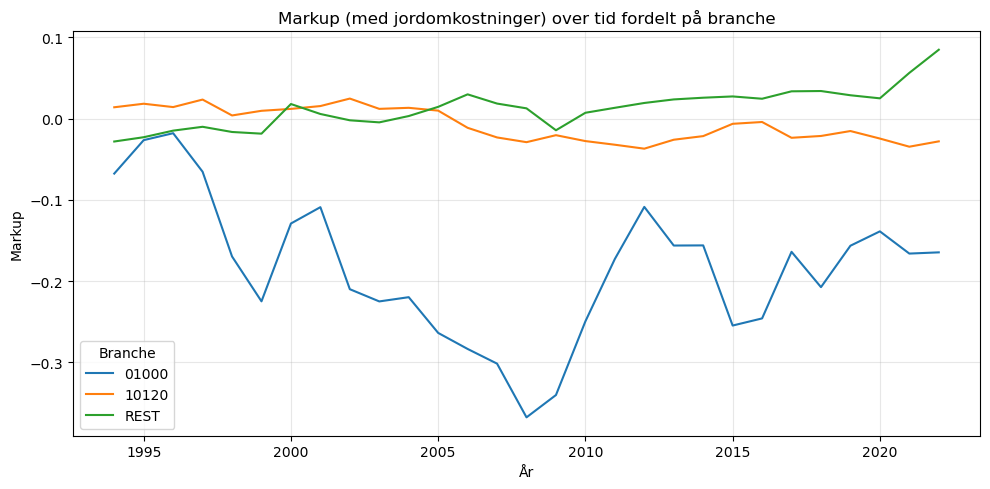

In [47]:
import matplotlib.pyplot as plt
# Kun 1993 og frem
d = calib.delta.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("δ (afskrivningsrate)")
plt.title("Afskrivningsrate (δ) over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
d = calib.P_K.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("User cost of capital")
plt.title("User cost of capital over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
d = calib.tau_MD.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("Afgiftsrate")
plt.title("Afgiftsrate over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
d = calib.P_J.loc[(slice(1994, 2022))].copy()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(d.index, d, label='Jordpris')

plt.xlabel("År")
plt.ylabel("Jordpris")
plt.title("Jordpris over tid")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
# Få data
d = df.J['Xt'].loc['01000', slice(1994, 2022)].copy()

# Plot
plt.figure(figsize=(10, 5))
# Udtræk tidsdimensionen fra MultiIndex
years = d.index.get_level_values('TID') if 'TID' in d.index.names else d.index
plt.plot(years, d.values, label='Jord')
plt.xlabel("År")
plt.ylabel("Jord")
plt.title("Jord over tid")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Kun 1993 og frem
d = calib.tau_Y.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("Subsidier")
plt.title("Subsidier over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
d = (calib.P_MxM_tot + calib.P_KLxKL) / df.Y['Xt']
markup=df.P['Pt']/((1+calib.tau_Y)*d)-1

# Gør den "wide": år som index, branche som kolonner
d_wide = markup.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("Markup")
plt.title("Markup (uden jordomkostninger) over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kun 1993 og frem
d = calib.markup.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("Markup")
plt.title("Markup (med jordomkostninger) over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Datatjeks